# Multi-Strategy Win Rate Analysis  NVDA
逐一测试以下策略的胜率：
1. **BB + MACD**
    * **skip BB Breakout + MACD Filter** 
        — 收盘价触及下/上轨，MACD金叉/死叉确认 
    * **v1 BB+MACD** (TODO: 趋势判断)
        - 价格bar大部分在下轨(必须)、1P/5P>21P(非必须), 5P上升趋势(必须), 13/21天price在波动/上升趋势(必须), volumn在50天及格线
        - 趋势判定: 用30天21P做线性拟合vs21天P做线性拟合vs随机抽点做线性拟合/多个拟合的中位数和方差相差大不大/'Savitzky-Golay'，均>0为上升势、0附近差别不大为波动势
2. **BB Squeeze + MACD Expansion** — 布林带收口后，MACD方向突破入场
3. **Mean Reversion** — 价格偏离中轨过远 + MACD动能减弱，逆向回归
4. **Trend Following** 
    * v1 — 价格沿上轨运行 + MACD零轴上方扩张，顺势持有(大趋势)
    * v2 - 纯凭趋势判断 + 买上升势 (TODO: 实现+多股)
5. **Gold X*** - 水上金叉买入, 10day/死叉退出
6. **Grid Strategy** 
    * 快慢线判断震荡市
    * 震荡市掉出下轨买入(TODO)
7. **大跌上量后第二天微升** - 大跌中间P挂单, 止盈上至80分位+严格止损

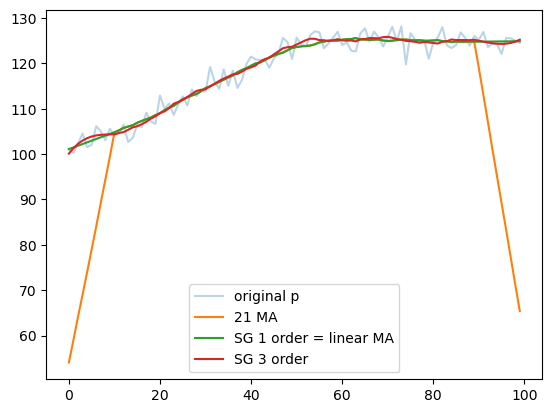

In [ ]:
import numpy as np    # 三种方法对比
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# 模拟一段先涨后震荡的价格
np.random.seed(42)
t = np.arange(100)
price = 100 + 0.5*t*(t<50) + 25*(t>=50) + np.random.randn(100)*2

# 三种方法
ma21 = np.convolve(price, np.ones(21)/21, mode='same')
sg_linear = savgol_filter(price, 21, polyorder=1)   # 等价于线性回归MA
sg_cubic  = savgol_filter(price, 21, polyorder=3)   # 3阶SG

plt.plot(price, alpha=0.3, label='original p')
plt.plot(ma21, label='21 MA')
plt.plot(sg_linear, label='SG 1 order = linear MA')
plt.plot(sg_cubic, label='SG 3 order')
plt.legend()

## 1. 数据获取（IBKR）

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

SYMBOL    = 'NVDA'
HOLD_DAYS = 5
INIT_CASH = 10000

# 直接读 BackBollingBand_NVDA.ipynb 保存的数据，无需重新连接 TWS
df_raw = pd.read_csv(f'data_{SYMBOL}.csv', parse_dates=['date'])
print(f'{SYMBOL}: {len(df_raw)} bars  {df_raw["date"].iloc[0].date()} → {df_raw["date"].iloc[-1].date()}')
df_raw.tail(3)

NVDA: 931 bars  2022-04-18 → 2025-12-31


,date,open,high,low,close,volume
928,2025-12-29,187.70,188.76,185.92,188.22,779741
929,2025-12-30,188.23,188.99,186.93,187.54,662000
930,2025-12-31,189.57,190.56,186.49,186.50,788216


## 2. 指标计算（BB + MACD）

In [ ]:
# '''Savitzky-Golay'''
# import numpy as np
# from scipy.signal import savgol_filter

# def classify_trend(prices, window=21, slope_threshold=0.001):
#     """
#     prices: 收盘价序列
#     window: 平滑窗口（天数，建议奇数）
#     slope_threshold: 斜率绝对值低于此认为是震荡
#     """
#     # # 一阶导数（趋势斜率），delta=1表示时间单位为1天
#     # slope = savgol_filter(prices, window_length=21, polyorder=3, deriv=1)
#     # # 二阶导数（趋势加速度，判断趋势是否在加速/减速）
#     # acceleration = savgol_filter(prices, window_length=21, polyorder=3, deriv=2)

#     smoothed = savgol_filter(prices, window_length=window, polyorder=3)
    
#     # 归一化斜率（相对于价格水平）
#     slope = np.gradient(smoothed) / smoothed
    
#     # 取最近N天的平均斜率判断当前状态
#     recent_slope = np.mean(slope[-5:])
    
#     if recent_slope > slope_threshold:
#         return "上升市", recent_slope
#     elif recent_slope < -slope_threshold:
#         return "下降市", recent_slope
#     else:
#         return "震荡市", recent_slope
    

In [3]:
from scipy.signal import savgol_filter as _sg_filter

def compute_price_trend(close_arr):
    """
    价格趋势综合判断，使用3类方法估算归一化斜率：
      M1. 21天原始价格线性拟合
      M2. 30天窗口内21日均线线性拟合
      M3. 21天窗口内6日均线线性拟合（16个点）
      M5. 指数加权线性拟合（λ=0.8，近端权重更大）
    取中位数后叠加 slope velocity 修正：
      velocity = 最近5天 median slope 的变化速率（内部滚动计算，无需外部状态）
      中位数 > 0.0005/天               → uptrend
      中位数 < -0.0005/天              → downtrend
      否则                             → fluctuation
    velocity 修正规则(DROP_THRESH)：
      uptrend     且 velocity < -0.00008          → 降级为 fluctuation
      fluctuation 且 velocity < -0.00016          → 降级为 downtrend
    最少需要 close_arr 长度 = 34（30天窗口 + 4天回溯）
    """
    n = len(close_arr)
    NEED = 34   # 30 (M2窗口) + 4 (velocity回溯)
    if n < NEED: return 'unknown'

    LAMBDA      = 0.8    # W3 - 指数加权, 越小近端权重越大
    DROP_THRESH = -0.00008
    VW          = 8   # velocity 回溯天数

    x21  = np.arange(21, dtype=float)
    wexp = np.array([LAMBDA ** (20 - i) for i in range(21)])

    def _one_median(arr_end_idx):
        """计算以 arr_end_idx 为末尾的21/30天窗口的 median slope。"""
        p21 = np.array(close_arr[arr_end_idx - 20 : arr_end_idx + 1], dtype=float)
        p30 = np.array(close_arr[arr_end_idx - 29 : arr_end_idx + 1], dtype=float)
        pmean = np.mean(p21)
        if pmean == 0: return None
        sl = []

        # M1: 均匀线性拟合
        s1, _ = np.polyfit(x21, p21, 1)
        sl.append(s1 / pmean)
        # M2: 30天内21日均线拟合
        ma = np.convolve(p30, np.ones(21) / 21, mode='valid')
        if len(ma) >= 3:
            s2, _ = np.polyfit(np.arange(len(ma), dtype=float), ma, 1)
            sl.append(s2 / np.mean(ma))
        # M3: 21天窗口内6日均线线性拟合（产生16个点）
        ma6 = np.convolve(p21, np.ones(6) / 6, mode='valid')
        if len(ma6) >= 3:
            s3, _ = np.polyfit(np.arange(len(ma6), dtype=float), ma6, 1)
            sl.append(s3 / np.mean(ma6))
        # M5: 指数加权拟合
        s5, _ = np.polyfit(x21, p21, 1, w=wexp)
        sl.append(s5 / pmean)
        return float(np.median(sl))


    # 计算最近 VW 天（含今天）的 median slope
    last_idx = n - 1
    med_history = []
    for offset in range(VW - 1, -1, -1):   # offset=4,3,2,1,0 → 由远到近
        idx = last_idx - offset
        if idx < 29:                        # 保证30天窗口不越界
            med_history.append(None)
        else:
            med_history.append(_one_median(idx))

    # 有效值不足时退化
    valid = [v for v in med_history if v is not None]
    if len(valid) == 0:
        return 'unknown'

    med = med_history[-1]   # 今天的 median
    if med is None: return 'unknown'

    # 基础判断
    if med > 0.0061:
        base = 'uptrend'
    elif med < -0.0061:
        base = 'downtrend'
    else:
        base = 'fluctuation'

    # # velocity 修正（需要 VW 个全部有效）
    # if all(v is not None for v in med_history):
    #     xv = np.arange(VW, dtype=float)
    #     velocity, _ = np.polyfit(xv, med_history, 1)
    #     if base == 'uptrend'     and velocity < DROP_THRESH:
    #         base = 'fluctuation'
    #     if base == 'fluctuation' and velocity < DROP_THRESH * 2:
    #         base = 'downtrend'

    return base

=== compute_price_trend spot-check ===
  t= 49: fluctuation
  t= 59: fluctuation
  t= 69: fluctuation
  t= 79: fluctuation
  t= 99: fluctuation


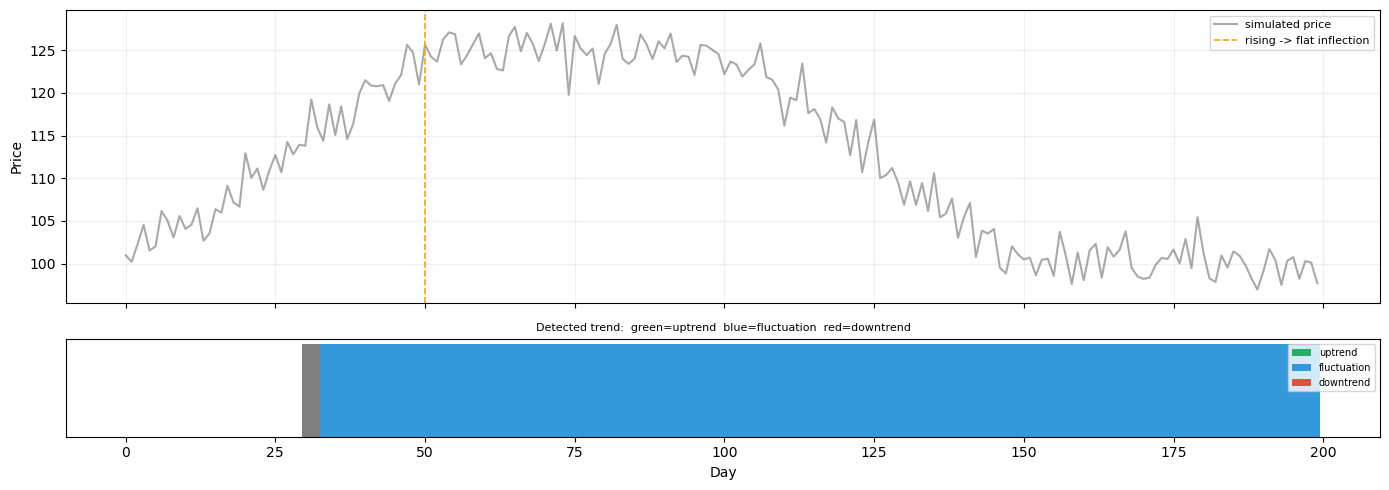

In [ ]:
# ── Test: compute_price_trend validation (rising then flat simulated price) ─────────
np.random.seed(42)
t_test = np.arange(200)

seg1 = 100 + 0.5 * t_test[:50]                          # 上升：100→125
seg2 = np.full(50, 125.0)                                # 震荡：125附近
seg3 = 125 - 0.5 * np.arange(50)                        # 下降：125→100
seg4 = np.full(50, 100.0)                                # 震荡：100附近
base = np.concatenate([seg1, seg2, seg3, seg4])
price_test = base + np.random.randn(200) * 2

print("=== compute_price_trend spot-check ===")
for i in [49, 59, 69, 79, 99]:
    print(f"  t={i:3d}: {compute_price_trend(price_test[:i+1])}")

# rolling window t=30..99
trend_labels = [(i, compute_price_trend(price_test[:i+1])) for i in range(30, len(price_test))]

color_map = {'uptrend': '#27AE60', 'fluctuation': '#3498DB',
             'downtrend': '#E74C3C', 'unknown': 'gray'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(t_test, price_test, alpha=0.5, color='#555', label='simulated price')
ax1.axvline(50, color='orange', lw=1.2, ls='--', label='rising -> flat inflection')
ax1.set_ylabel('Price')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.2)
# ax1.set_title('compute_price_trend test  (t<50 rising / t>=50 flat)', fontsize=10)

xs = [x for x, _ in trend_labels]
cs = [color_map.get(l, 'gray') for _, l in trend_labels]
ax2.bar(xs, [1]*len(xs), color=cs, width=1.0)
ax2.set_yticks([])
ax2.set_xlabel('Day')
ax2.set_title('Detected trend:  green=uptrend  blue=fluctuation  red=downtrend', fontsize=8)

from matplotlib.patches import Patch
ax2.legend(handles=[Patch(facecolor=v, label=k) for k, v in color_map.items() if k != 'unknown'],
           loc='upper right', fontsize=7)

plt.tight_layout()
plt.show()

In [4]:
def add_indicators(df, bb_window=20, bb_std=2.0,
                   macd_fast=12, macd_slow=26, macd_signal=9):
    df = df.copy()

    # ── 布林带 ────────────────────────────────────────
    df['bb_mid']   = df['close'].rolling(bb_window).mean()
    df['bb_std']   = df['close'].rolling(bb_window).std()
    df['bb_upper'] = df['bb_mid'] + bb_std * df['bb_std']
    df['bb_lower'] = df['bb_mid'] - bb_std * df['bb_std']
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_mid']
    df['bb_pct']   = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

    # ── MACD ──────────────────────────────────────────
    ema_fast            = df['close'].ewm(span=macd_fast,   adjust=False).mean()
    ema_slow            = df['close'].ewm(span=macd_slow,   adjust=False).mean()
    df['dif']           = ema_fast - ema_slow
    df['dea']           = df['dif'].ewm(span=macd_signal, adjust=False).mean()
    df['macd_bar']      = (df['dif'] - df['dea']) * 2
    df['macd_bar_prev'] = df['macd_bar'].shift(1)
    df['dif_prev']      = df['dif'].shift(1)
    df['dea_prev']      = df['dea'].shift(1)

    # ── 偏离中轨 ──────────────────────────────────────
    df['dev_from_mid'] = (df['close'] - df['bb_mid']) / df['bb_mid']

    # ── 策略一专用指标 ────────────────────────────────
    df['ma5']      = df['close'].rolling(5).mean()
    df['ma21']     = df['close'].rolling(21).mean()
    df['vol_ma50'] = df['volume'].rolling(50).mean()

    # 近下轨标记：bb_pct ≤ 0.50（布林带下50%区间内）
    df['near_lower']      = (df['bb_pct'] <= 0.50).astype(int)
    # df['near_lower_cnt7'] = df['near_lower'].rolling(7).sum()   # 近7根中达标数
    def _has_consec3(x):
        for i in range(len(x) - 2):
            if x[i] == 1 and x[i+1] == 1 and x[i+2] == 1:
                return 1.0
        return 0.0
    df['near_lower_consec3'] = df['near_lower'].rolling(7).apply(_has_consec3, raw=True)


    # MA5上升趋势：当日MA5 > 前日MA5
    df['ma5_rising'] = (df['ma5'] > df['ma5'].shift(1)).astype(int)

    # 13/21天综合趋势（逐行计算，首30行为unknown）
    close_vals = df['close'].values
    trend_list = ['unknown'] * len(df)
    for i in range(30, len(df)):
        trend_list[i] = compute_price_trend(close_vals[:i + 1])
    df['trend_13_21'] = trend_list

    return df

df = add_indicators(df_raw)
print('指标计算完成，列：', [c for c in df.columns if c not in df_raw.columns])
df[['date','close','bb_lower','bb_upper','bb_width','dif','dea','macd_bar']].tail(5)

指标计算完成，列： ['bb_mid', 'bb_std', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct', 'dif', 'dea', 'macd_bar', 'macd_bar_prev', 'dif_prev', 'dea_prev', 'dev_from_mid', 'ma5', 'ma21', 'vol_ma50', 'near_lower', 'near_lower_consec3', 'ma5_rising', 'trend_13_21']


,date,close,bb_lower,bb_upper,bb_width,dif,dea,macd_bar
926,2025-12-24,188.61,171.385003,190.200997,0.104075,-0.373787,-1.721361,2.695148
927,2025-12-26,190.53,170.947920,191.665080,0.114266,0.328080,-1.311473,3.279105
928,2025-12-29,188.22,171.278211,192.456789,0.116451,0.689963,-0.911186,3.202296
929,2025-12-30,187.54,171.408872,193.088128,0.118954,0.911381,-0.546672,2.916107
930,2025-12-31,186.50,171.504839,193.496161,0.120500,0.991508,-0.239036,2.461089


## 3. 通用回测引擎

In [5]:
def run_strategy(df, signal_func, hold_days=HOLD_DAYS,
                 init_cash=INIT_CASH, buy_pct=0.20, fee=0.0005,
                 tp_pct=None, sl_pct=None):
    """
    通用回测引擎。
    signal_func(row, prev_row) → 'BUY' / None
    tp_pct: 止盈比例，如 0.05 = 涨5%止盈（None = 不用）
    sl_pct: 止损比例，如 0.03 = 跌3%止损（None = 不用）
    hold_days: 固定持仓天数（tp/sl 都没触发时的兜底，None = 不用）
    """
    df = df.dropna().reset_index(drop=True)
    cash, position, entry_bar, entry_price = init_cash, 0.0, None, None
    trades, equity_curve = [], []

    for i in range(1, len(df)):
        row      = df.iloc[i]
        prev_row = df.iloc[i - 1]
        close    = float(row['close'])
        date     = row['date']

        # ── 卖出判断 ──────────────────────────────────
        if entry_bar is not None and position > 0:
            days_held = i - entry_bar
            ret       = (close - entry_price) / entry_price

            do_sell     = False
            sell_reason = ''

            if tp_pct is not None and ret >= tp_pct:
                do_sell = True; sell_reason = f'TP +{ret:.1%}'
            elif sl_pct is not None and ret <= -sl_pct:
                do_sell = True; sell_reason = f'SL {ret:.1%}'
            elif hold_days is not None and days_held >= hold_days:
                do_sell = True; sell_reason = f'Hold {days_held}d'

            if do_sell:
                proceeds = position * close
                cash    += proceeds * (1 - fee)
                cost     = entry_price * position * (1 + fee)
                trades.append({
                    'entry_date':  df.iloc[entry_bar]['date'],
                    'exit_date':   date,
                    'entry_price': entry_price,
                    'exit_price':  close,
                    'shares':      round(position, 4),
                    'cost':        round(cost, 2),
                    'proceeds':    round(proceeds, 2),
                    'pnl':         round(proceeds * (1 - fee) - cost, 2),
                    'reason':      sell_reason,
                })
                position, entry_bar, entry_price = 0.0, None, None

        # ── 买入判断 ──────────────────────────────────
        sig = signal_func(row, prev_row)
        if sig == 'BUY' and entry_bar is None and cash > 0:
            spend        = cash * buy_pct
            shares       = spend / close
            cash        -= spend * (1 + fee)
            position     = shares
            entry_bar    = i
            entry_price  = close

        equity_curve.append({'date': date, 'equity': cash + position * close})

    trades_df = pd.DataFrame(trades)
    if len(trades_df) > 0:
        trades_df['win']     = trades_df['pnl'] > 0
        trades_df['pnl_pct'] = trades_df['pnl'] / trades_df['cost'] * 100
    return pd.DataFrame(equity_curve), trades_df


def win_rate_summary(name, trades_df):
    if len(trades_df) == 0:
        print(f'{name}: 无交易')
        return {}
    wins     = trades_df['win'].sum()
    total    = len(trades_df)
    wr       = wins / total * 100
    avg_pnl  = trades_df['pnl'].mean()
    avg_win  = trades_df.loc[trades_df['win'],  'pnl'].mean() if wins > 0 else 0
    avg_loss = trades_df.loc[~trades_df['win'], 'pnl'].mean() if (total - wins) > 0 else 0
    rr       = abs(avg_win / avg_loss) if avg_loss != 0 else float('inf')
    print(f'[{name}]  Trades={total}  WinRate={wr:.1f}%  '
          f'AvgPnL=${avg_pnl:.1f}  AvgWin=${avg_win:.1f}  AvgLoss=${avg_loss:.1f}  R:R={rr:.2f}')
    return {'name': name, 'trades': total, 'win_rate': round(wr, 1),
            'avg_pnl': round(avg_pnl, 2), 'avg_win': round(avg_win, 2),
            'avg_loss': round(avg_loss, 2), 'rr': round(rr, 2)}

print('通用回测引擎更新完成（支持 tp_pct / sl_pct）')

通用回测引擎更新完成（支持 tp_pct / sl_pct）


## 4. 策略一v2：BB Lower v2 — 下轨积累反弹
  **入场条件（均为必须）：**
- 近 7 根 bar 中 ≥ 4 根 bb_pct ≤ 0.20（大部分价格紧贴 BB 下轨区域）
- MA5 当日 > 前日（短期均线已开始抬头）
- 过去 13–21 天价格趋势为**上升势**或**震荡势**（4 种方法综合：21天拟合 / 30天内21P均线拟合 / 随机抽点拟合×5 / Savitzky-Golay；取斜率中位数，>0.03%/天=上升，|≤0.04%|且std小=震荡）
- 当日成交量 ≥ 50 日均量（量能及格）

  **软过滤（非必须，参考用）：** 当前价格 or MA5 > MA21 
  止盈 8% / 止损 5% / 兜底持仓 10 天

In [33]:
def signal_bb_lower_v2(row, prev):
    """
    [必须] BB下轨 - 近7根bar 连续3根bar在BB下轨 bb_pct (替代:近7根bar ≥ 3根 bb_pct
    [必须] MA5当日 > 前日（短期趋势抬头）
    [必须] 13/21天综合趋势 in ('uptrend', 'fluctuation')（不能是长期下降势）
    [必须] 当日成交量 ≥ 50日均量
    [必须] 下单当天的bar大部分在下轨
    [非必须] 当前价格 or MA5 > MA21（软过滤，不作硬性条件）
    """
    # near_lower_ok = row['near_lower_cnt7'] >= 4
    near_lower_ok = row['near_lower_consec3'] == 1.0

    ma5_up        = row['ma5_rising'] == 1
    trend_ok      = row['trend_13_21'] in ('uptrend', 'fluctuation')
    # vol_ok        = row['volume'] >= row['vol_ma50']
    # entry-day bar: >= 50% of high-low range below bb_lower
    bar_in_lower_ok = (min(row['low'], row['close'])) < row['bb_mid']


    if near_lower_ok and ma5_up and trend_ok  and bar_in_lower_ok: return 'BUY'
    return None # and vol_ok

eq1, tr1 = run_strategy(df, signal_bb_lower_v2,
                        hold_days=10,
                        tp_pct=0.1,
                        sl_pct=0.06)

s1 = win_rate_summary('1.BB Lower v2 + TP8% SL5% Hold10d', tr1)

if len(tr1) > 0:
    print('\n卖出原因分布:')
    print(tr1['reason'].value_counts())

    # 软过滤参考：同时满足非必须条件的信号占比
    df_clean = df.dropna().reset_index(drop=True)
    soft_signals = df_clean[
        (df_clean['near_lower_consec3'] == 1.0) &
        (df_clean['ma5_rising'] == 1) &
        (df_clean['trend_13_21'].isin(['uptrend', 'fluctuation'])) &
        # (df_clean['volume'] >= df_clean['vol_ma50']) &
        ((df_clean['close'] > df_clean['ma21']) | (df_clean['ma5'] > df_clean['ma21']))
    ]
    total_triggered = len(df_clean[
        (df_clean['near_lower_consec3'] == 1.0) &
        (df_clean['ma5_rising'] == 1) &
        (df_clean['trend_13_21'].isin(['uptrend', 'fluctuation'])) 
        # & (df_clean['volume'] >= df_clean['vol_ma50'])
    ])
    print(f'\n[soft filter ref] price/MA5 > MA21 signals: {len(soft_signals)} '
        f'vs total triggered: {total_triggered}')
    
    # 展示趋势分布
    trend_dist = df_clean.loc[df_clean['trend_13_21'] != 'unknown', 'trend_13_21'].value_counts()
    print(f'\n全样本趋势分布:\n{trend_dist.to_string()}')

tr1

[1.BB Lower v2 + TP8% SL5% Hold10d]  Trades=22  WinRate=59.1%  AvgPnL=$239.2  AvgWin=$913.8  AvgLoss=$-735.3  R:R=1.24

卖出原因分布:
reason
Hold 10d     8
TP +12.4%    1
TP +11.5%    1
TP +16.2%    1
TP +12.2%    1
TP +10.0%    1
SL -7.3%     1
SL -8.0%     1
SL -7.0%     1
TP +10.9%    1
SL -14.0%    1
SL -8.3%     1
TP +10.3%    1
SL -6.0%     1
TP +13.0%    1
Name: count, dtype: int64

[soft filter ref] price/MA5 > MA21 signals: 88 vs total triggered: 122

全样本趋势分布:
trend_13_21
fluctuation    534
uptrend        264
downtrend       84


,entry_date,exit_date,entry_price,exit_price,shares,cost,proceeds,pnl,reason,win,pnl_pct
0,2022-07-08,2022-07-20,15.84,17.81,631.3131,10005.00,11243.69,1233.07,TP +12.4%,True,12.324538
1,2022-10-17,2022-10-25,11.89,13.26,861.7841,10251.74,11427.26,1169.81,TP +11.5%,True,11.410843
2,2023-01-12,2023-01-23,16.51,19.19,634.8016,10485.81,12181.84,1689.94,TP +16.2%,True,16.116447
3,2023-04-20,2023-05-04,27.10,27.56,399.2089,10823.97,11002.20,172.73,Hold 10d,True,1.595810
4,2023-08-16,2023-08-29,43.49,48.78,249.5541,10858.53,12173.25,1308.63,TP +12.2%,True,12.051631
5,2023-10-02,2023-10-16,44.78,46.10,248.2098,11120.39,11442.47,316.36,Hold 10d,True,2.844864
6,2023-11-01,2023-11-08,42.33,46.57,264.0705,11183.69,12297.76,1107.92,TP +10.0%,True,9.906569
7,2023-12-08,2023-12-22,47.51,48.83,239.9429,11405.39,11716.41,305.17,Hold 10d,True,2.675665
8,2024-04-11,2024-04-17,90.62,84.04,126.4701,11466.45,10628.55,-843.22,SL -7.3%,False,-7.353802
9,2024-04-26,2024-05-10,87.74,89.88,128.6993,11297.72,11567.49,263.99,Hold 10d,True,2.336666


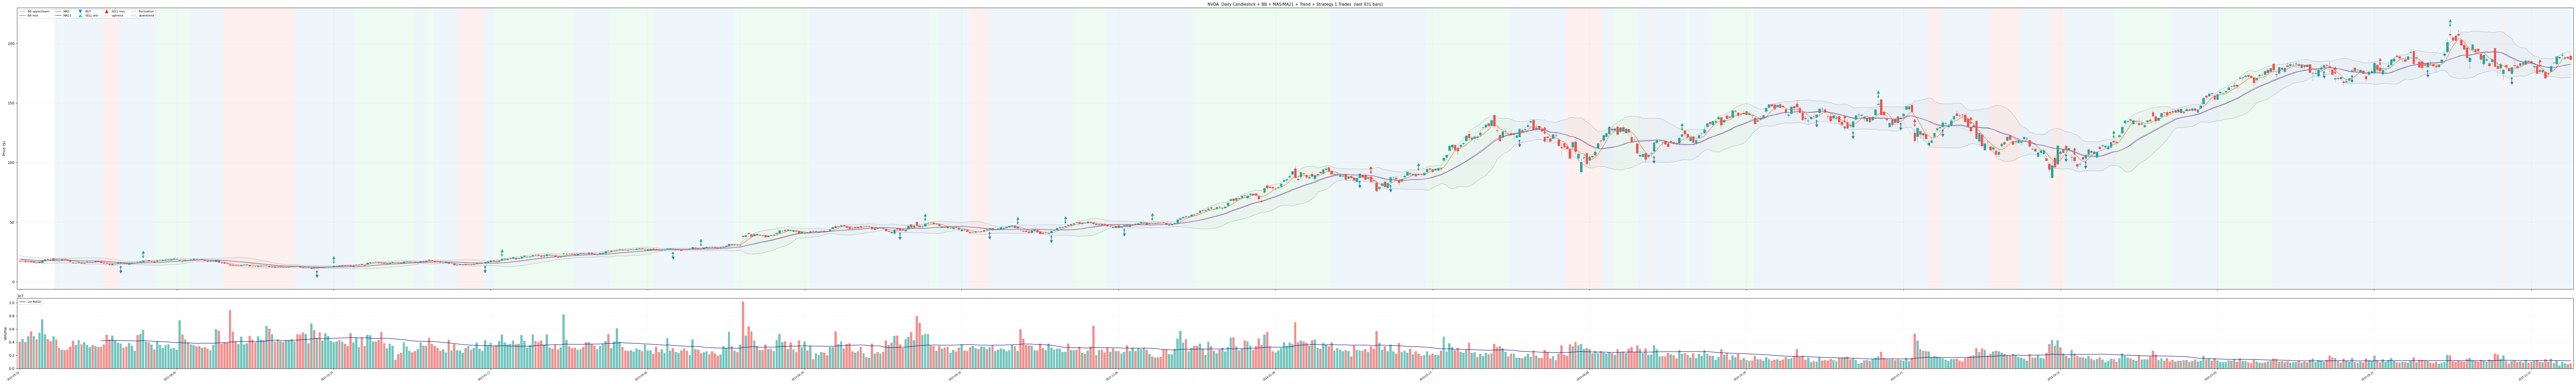

In [35]:
# from matplotlib.patches import Patch
# from matplotlib.lines import Line2D

NBAR = 931#100   # number of bars to display (set to len(df) for full history)

plot_df = (df.dropna(subset=['bb_mid', 'ma5', 'ma21', 'trend_13_21'])
             .tail(NBAR).reset_index(drop=True))
xs = np.arange(len(plot_df))

# date → x-axis index lookup
date_to_x = {d: i for i, d in enumerate(plot_df['date'])}

# ── figure layout ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(100, 15), sharex=True,
                                gridspec_kw={'height_ratios': [4, 1]})

# ── trend background shading ──────────────────────────────────────────────────
TREND_CLR = {'uptrend': '#d5f5e3', 'fluctuation': '#d6eaf8',
             'downtrend': '#fadbd8', 'unknown': 'white'}

seg_start, prev_t = 0, plot_df['trend_13_21'].iloc[0]
for i, t in enumerate(plot_df['trend_13_21']):
    if t != prev_t:
        ax1.axvspan(seg_start - 0.5, i - 0.5, color=TREND_CLR.get(prev_t, 'white'),
                    alpha=0.40, lw=0)
        seg_start, prev_t = i, t
ax1.axvspan(seg_start - 0.5, len(plot_df) - 0.5,
            color=TREND_CLR.get(prev_t, 'white'), alpha=0.40, lw=0)

# ── candlesticks ──────────────────────────────────────────────────────────────
for i, row in plot_df.iterrows():
    up     = row['close'] >= row['open']
    body_c = '#26a69a' if up else '#ef5350'
    lo, hi = min(row['open'], row['close']), max(row['open'], row['close'])
    ax1.plot([i, i], [row['low'], row['high']], color=body_c, lw=0.7, zorder=2)
    ax1.add_patch(plt.Rectangle((i - 0.35, lo), 0.70, max(hi - lo, 0.01),
                                 color=body_c, zorder=3))

# ── Bollinger Bands ───────────────────────────────────────────────────────────
ax1.plot(xs, plot_df['bb_upper'], color='#95a5a6', lw=0.9, ls='--')
ax1.plot(xs, plot_df['bb_mid'],   color='#7f8c8d', lw=1.0, ls='-')
ax1.plot(xs, plot_df['bb_lower'], color='#95a5a6', lw=0.9, ls='--')
ax1.fill_between(xs, plot_df['bb_lower'], plot_df['bb_upper'],
                 alpha=0.05, color='gray')

# ── MA5 / MA21 ────────────────────────────────────────────────────────────────
ax1.plot(xs, plot_df['ma5'],  color='#e67e22', lw=1.2, label='MA5')
ax1.plot(xs, plot_df['ma21'], color='#8e44ad', lw=1.2, label='MA21')

# ── buy / sell markers from tr1 ───────────────────────────────────────────────
price_range = plot_df['high'].max() - plot_df['low'].min()
offset = price_range * 0.025   # vertical offset so arrows don't overlap candles

for _, t in tr1.iterrows():
    xi = date_to_x.get(t['entry_date'])
    xo = date_to_x.get(t['exit_date'])
    win_c  = '#27ae60' if t['win'] else '#e74c3c'

    # BUY arrow: upward triangle below the low
    if xi is not None:
        low_here = plot_df.loc[xi, 'low']
        ax1.annotate('', xy=(xi, low_here - offset * 0.2),
                     xytext=(xi, low_here - offset * 1.4),
                     arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.8),
                     zorder=6)
        ax1.plot(xi, low_here - offset * 1.4, 'v',
                 color='#2980b9', ms=7, zorder=6)

    # SELL arrow: downward triangle above the high, colored by win/loss
    if xo is not None:
        high_here = plot_df.loc[xo, 'high']
        ax1.annotate('', xy=(xo, high_here + offset * 0.2),
                     xytext=(xo, high_here + offset * 1.4),
                     arrowprops=dict(arrowstyle='->', color=win_c, lw=1.8),
                     zorder=6)
        ax1.plot(xo, high_here + offset * 1.4, '^',
                 color=win_c, ms=7, zorder=6)

    # dashed line connecting entry to exit (both visible)
    if xi is not None and xo is not None:
        ax1.plot([xi, xo], [t['entry_price'], t['exit_price']],
                 color=win_c, lw=0.8, ls=':', alpha=0.6, zorder=5)

ax1.set_ylabel('Price ($)')
ax1.set_title(f'NVDA  Daily Candlestick + BB + MA5/MA21 + Trend + Strategy 1 Trades  (last {NBAR} bars)',
              fontsize=11)
ax1.grid(alpha=0.15)
ax1.set_xlim(-1, len(plot_df))

# legend
line_handles = [
    Line2D([0], [0], color='#95a5a6', ls='--', label='BB upper/lower'),
    Line2D([0], [0], color='#7f8c8d', ls='-',  label='BB mid'),
    Line2D([0], [0], color='#e67e22', lw=1.5,  label='MA5'),
    Line2D([0], [0], color='#8e44ad', lw=1.5,  label='MA21'),
    Line2D([0], [0], marker='v', color="#0797f7", ls='none', ms=8, label='BUY'),
    Line2D([0], [0], marker='^', color="#05f76a", ls='none', ms=8, label='SELL win'),
    Line2D([0], [0], marker='^', color="#f71c03", ls='none', ms=8, label='SELL loss'),
]
trend_handles = [
    Patch(facecolor='#d5f5e3', alpha=0.7, label='uptrend'),
    Patch(facecolor='#d6eaf8', alpha=0.7, label='fluctuation'),
    Patch(facecolor='#fadbd8', alpha=0.7, label='downtrend'),
]
ax1.legend(handles=line_handles + trend_handles, fontsize=8,
           loc='upper left', ncol=5, framealpha=0.85)

# ── volume bars ───────────────────────────────────────────────────────────────
vol_c = ['#26a69a' if plot_df['close'].iloc[i] >= plot_df['open'].iloc[i]
         else '#ef5350' for i in range(len(plot_df))]
ax2.bar(xs, plot_df['volume'], color=vol_c, alpha=0.65, width=0.8)
ax2.plot(xs, plot_df['vol_ma50'], color='navy', lw=1.1, label='vol MA50')
ax2.set_ylabel('Volume')
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(alpha=0.15)

# ── x-axis date ticks ─────────────────────────────────────────────────────────
step = max(1, len(plot_df) // 16)
ax2.set_xticks(xs[::step])
ax2.set_xticklabels([str(plot_df['date'].iloc[i].date()) for i in xs[::step]],
                    rotation=35, ha='right', fontsize=7)

plt.tight_layout()
# plt.savefig('nvda_candle_bb_ma_trend.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# ## 4. 策略一v1：BB Lower Touch
# # 收盘价触及 BB 下轨 → 买入；涨 8% 止盈 / 跌 5% 止损

# def signal_bb_lower(row, prev):
#     """收盘价触及 BB 下轨即买入（不加 MACD 过滤）"""
#     if row['close'] <= row['bb_lower']:
#         return 'BUY'
#     return None

# eq1, tr1 = run_strategy(df, signal_bb_lower,
#                         hold_days=10,     # 兜底：最多持仓10天
#                         tp_pct=0.08,      # 涨5%止盈
#                         sl_pct=0.05)      # 跌3%止损

# s1 = win_rate_summary('1.BB Lower + TP8% SL5% Hold10d', tr1)

# if len(tr1) > 0:
#     print('\n卖出原因分布:')
#     print(tr1['reason'].value_counts())
# tr1

[1.BB Lower + TP8% SL5% Hold10d]  Trades=17  WinRate=70.6%  AvgPnL=$531.5  AvgWin=$1077.9  AvgLoss=$-779.7  R:R=1.38

卖出原因分布:
reason
Hold 10d     2
TP +10.7%    2
SL -7.2%     1
SL -7.6%     1
SL -5.8%     1
TP +10.4%    1
TP +9.2%     1
TP +11.6%    1
TP +8.2%     1
SL -9.2%     1
TP +12.8%    1
TP +8.9%     1
TP +10.0%    1
SL -7.4%     1
TP +21.2%    1
Name: count, dtype: int64


,entry_date,exit_date,entry_price,exit_price,shares,cost,proceeds,pnl,reason,win,pnl_pct
0,2022-08-26,2022-08-31,16.26,15.09,615.0062,10005.00,9280.44,-729.20,SL -7.2%,False,-7.288356
1,2022-08-31,2022-09-01,15.09,13.94,653.0259,9859.09,9103.18,-760.46,SL -7.6%,False,-7.713288
2,2022-09-01,2022-09-13,13.94,13.13,695.9877,9706.92,9138.32,-573.17,SL -5.8%,False,-5.904757
3,2022-10-10,2022-10-24,11.67,12.60,821.5454,9592.23,10351.47,754.07,Hold 10d,True,7.861259
4,2022-12-27,2023-01-09,14.12,15.63,689.6776,9743.12,10779.66,1031.15,TP +10.7%,True,10.583365
5,2023-08-09,2023-08-21,42.55,46.97,233.7128,9949.45,10977.49,1022.55,TP +10.4%,True,10.277453
6,2023-09-21,2023-10-02,41.02,44.78,247.4156,10154.06,11079.27,919.67,TP +9.2%,True,9.057165
7,2023-10-26,2023-11-03,40.33,45.01,256.2093,10338.09,11531.98,1188.13,TP +11.6%,True,11.492742
8,2024-04-19,2024-04-23,76.20,82.42,138.7211,10575.83,11433.39,851.84,TP +8.2%,True,8.054592
9,2024-07-24,2024-07-30,114.25,103.73,94.0124,10746.29,9751.91,-999.26,SL -9.2%,False,-9.298651


## 5. 策略二：BB Squeeze + MACD Expansion
布林带宽收缩到历史低位（低波动期）→ MACD 柱向下扩张方向入场

In [38]:
BB_SQUEEZE_PCTILE = 20   # 带宽低于过去60日的20%分位 = 收口
df['bb_width_pctile'] = df['bb_width'].rolling(60).apply(
    lambda x: 1.0 if x[-1] <= np.percentile(x, BB_SQUEEZE_PCTILE) else 0.0,
    raw=True
)

def signal_squeeze_expansion(row, prev):
    """
    布林带处于收口期（bb_width 低于近60日的20%分位）
    + MACD 柱子由负转正（向上突破）
    """
    squeeze        = row['bb_width_pctile'] == 1.0
    macd_expand_up = (prev['macd_bar'] < 0) and (row['macd_bar'] > 0)
    if squeeze and macd_expand_up:
        return 'BUY'
    return None

eq2, tr2 = run_strategy(df, signal_squeeze_expansion,
                        hold_days=None,   # 不用固定天数
                        tp_pct=0.08,      # 涨8%止盈
                        sl_pct=0.05)      # 跌5%止损

s2 = win_rate_summary('2.BB Squeeze+MACD + TP8% SL5%', tr2)

if len(tr2) > 0:
    print('\n卖出原因分布:')
    print(tr2['reason'].value_counts())
tr2

[2.BB Squeeze+MACD + TP8% SL5%]  Trades=6  WinRate=50.0%  AvgPnL=$149.4  AvgWin=$891.2  AvgLoss=$-592.5  R:R=1.50

卖出原因分布:
reason
SL -6.2%     1
SL -5.5%     1
TP +8.7%     1
SL -5.9%     1
TP +10.6%    1
TP +8.1%     1
Name: count, dtype: int64


,entry_date,exit_date,entry_price,exit_price,shares,cost,proceeds,pnl,reason,win,pnl_pct
0,2022-08-15,2022-08-19,19.03,17.85,525.4861,10005.00,9379.93,-629.76,SL -6.2%,False,-6.294453
1,2022-12-12,2022-12-16,17.54,16.57,562.9445,9878.98,9327.99,-555.66,SL -5.5%,False,-5.624670
2,2023-12-15,2024-01-09,48.89,53.14,199.6915,9767.80,10611.60,838.50,TP +8.7%,True,8.584328
3,2024-11-07,2024-11-18,148.88,140.15,66.7022,9935.58,9348.31,-591.95,SL -5.9%,False,-5.957881
4,2025-06-25,2025-07-15,154.31,170.70,63.5878,9817.13,10854.43,1031.87,TP +10.6%,True,10.510913
5,2025-10-27,2025-10-29,191.49,207.04,52.3192,10023.61,10832.16,803.14,TP +8.1%,True,8.012483


## 6. 策略三：均值回归
收盘价偏离BB中轨过远（偏低）+ MACD动能减弱 → 做多回归

In [39]:
DEV_THRESHOLD = -0.04   # 价格偏离中轨 -4% 以上触发

def signal_mean_reversion(row, prev):
    """
    收盘价偏离BB中轨 < -4%（超卖）
    + MACD 柱子动能减弱（负值但绝对值缩小，即空头力量减弱）
    """
    oversold       = row['dev_from_mid'] < DEV_THRESHOLD
    macd_weakening = (row['macd_bar'] < 0) and (abs(row['macd_bar']) < abs(prev['macd_bar']))
    if oversold and macd_weakening:
        return 'BUY'
    return None

eq3, tr3 = run_strategy(df, signal_mean_reversion)
s3 = win_rate_summary('3.Mean Reversion', tr3)
tr3.head(5)

[3.Mean Reversion]  Trades=21  WinRate=61.9%  AvgPnL=$273.1  AvgWin=$747.3  AvgLoss=$-497.5  R:R=1.50


,entry_date,exit_date,entry_price,exit_price,shares,cost,proceeds,pnl,reason,win,pnl_pct
0,2022-09-07,2022-09-14,13.71,13.13,729.3946,10005.00,9576.95,-432.84,Hold 5d,False,-4.326237
1,2022-09-14,2022-09-21,13.13,13.26,755.0215,9918.39,10011.59,88.19,Hold 5d,True,0.889156
2,2022-09-21,2022-09-28,13.26,12.74,748.9495,9936.04,9541.62,-399.19,Hold 5d,False,-4.017597
3,2022-12-29,2023-01-06,14.60,14.86,674.7420,9856.16,10026.67,165.49,Hold 5d,True,1.679051
4,2023-01-06,2023-01-13,14.86,16.90,665.1636,9889.27,11241.27,1346.37,Hold 5d,True,13.614453


## 7. 策略四：趋势跟踪
1. 价格沿上轨运行 + MACD零轴上方扩张 → 顺势做多
2. 按趋势判断 + 上升势开始-买入 上升势结束-平仓

In [ ]:
def signal_trend_following(row, prev):
    """
    价格沿上轨运行：close > bb_mid（价格在中轨上方）
    + %B > 0.7（接近上轨）
    + MACD 在零轴上方且柱子扩张（趋势延续）
    """
    above_mid    = row['close'] > row['bb_mid']
    near_upper   = row['bb_pct'] > 0.7
    macd_bullish = (row['dif'] > 0) and (row['dea'] > 0)
    macd_expand  = row['macd_bar'] > prev['macd_bar'] and row['macd_bar'] > 0
    if above_mid and near_upper and macd_bullish and macd_expand:
        return 'BUY'
    return None

eq4, tr4 = run_strategy(df, signal_trend_following,
                        hold_days=10,   # 不用固定天数
                        tp_pct=0.10,      # 涨8%止盈
                        sl_pct=0.05)      # 跌5%止损

s4 = win_rate_summary('4.Trend Following + TP10% SL5%', tr4)

if len(tr4) > 0:
    print('\n卖出原因分布:')
    print(tr4['reason'].value_counts())
tr4.head(10)

[4.Trend Following + TP10% SL5%]  Trades=40  WinRate=70.0%  AvgPnL=$384.0  AvgWin=$844.1  AvgLoss=$-689.8  R:R=1.22

卖出原因分布:
reason
Hold 10d     22
SL -5.5%      2
SL -6.2%      1
TP +12.5%     1
SL -19.6%     1
SL -5.9%      1
TP +12.4%     1
SL -5.7%      1
SL -8.9%      1
TP +10.6%     1
TP +11.7%     1
TP +10.1%     1
TP +11.2%     1
TP +13.9%     1
TP +30.0%     1
TP +13.1%     1
TP +10.4%     1
TP +10.0%     1
Name: count, dtype: int64


,entry_date,exit_date,entry_price,exit_price,shares,cost,proceeds,pnl,reason,win,pnl_pct
0,2022-08-15,2022-08-19,19.03,17.85,525.4861,10005.00,9379.93,-629.76,SL -6.2%,False,-6.294453
1,2022-11-07,2022-11-10,14.30,15.75,690.4928,9878.98,10875.26,990.84,TP +10.1%,True,10.029780
2,2022-11-10,2022-11-25,15.75,16.27,639.5057,10077.25,10404.76,322.30,Hold 10d,True,3.198293
3,2022-11-30,2022-12-06,16.92,15.99,599.0943,10141.74,9579.52,-567.02,SL -5.5%,False,-5.590954
4,2022-12-12,2022-12-16,17.54,16.57,571.4523,10028.28,9468.96,-564.05,SL -5.5%,False,-5.624594
5,2023-01-18,2023-01-23,17.38,19.19,570.2222,9915.42,10942.56,1021.68,TP +10.4%,True,10.303951
6,2023-01-23,2023-02-02,19.19,21.71,527.0869,10119.85,11443.06,1317.48,TP +13.1%,True,13.018770
7,2023-02-02,2023-02-16,21.71,22.00,478.0421,10383.48,10516.93,128.18,Hold 10d,True,1.234461
8,2023-03-16,2023-03-30,25.54,27.38,407.3583,10409.13,11153.47,738.76,Hold 10d,True,7.097231
9,2023-03-30,2023-04-14,27.38,26.76,385.3792,10556.96,10312.75,-249.37,Hold 10d,False,-2.362138


In [8]:
def run_strat4_trend(df, init_cash=INIT_CASH, buy_pct=0.20, fee=0.005, sl_pct=0.05):
    """
    Buy:  trend_13_21 transitions into 'uptrend'
    Sell: trend_13_21 transitions away from 'uptrend' (-> fluctuation / downtrend)
          OR hard stop-loss sl_pct triggered
    """
    df = df.dropna().reset_index(drop=True)
    cash, position, entry_bar, entry_price = init_cash, 0.0, None, None
    trades, equity_curve = [], []

    for i in range(1, len(df)):
        row   = df.iloc[i]
        prev  = df.iloc[i - 1]
        close = float(row['close'])
        date  = row['date']

        # ── Exit ──────────────────────────────────────────────────────
        if entry_bar is not None and position > 0:
            trend_flip = (prev['trend_13_21'] == 'uptrend' and
                          row['trend_13_21']  != 'uptrend')
            sl_hit     = (close - entry_price) / entry_price <= -sl_pct

            if trend_flip or sl_hit:
                reason   = (f"Trend->{row['trend_13_21']}" if trend_flip else f"SL {(close - entry_price) / entry_price:.1%}")
                proceeds = position * close
                cash    += proceeds * (1 - fee)
                cost     = entry_price * position * (1 + fee)
                trades.append({
                    'entry_date':  df.iloc[entry_bar]['date'],
                    'exit_date':   date,
                    'entry_price': entry_price,
                    'exit_price':  close,
                    'shares':      round(position, 4),
                    'cost':        round(cost, 2),
                    'proceeds':    round(proceeds, 2),
                    'pnl':         round(proceeds * (1 - fee) - cost, 2),
                    'reason':      reason,
                })
                position, entry_bar, entry_price = 0.0, None, None

        # ── Entry: uptrend just turned on ─────────────────────────────
        if (prev['trend_13_21'] != 'uptrend' and
                row['trend_13_21'] == 'uptrend' and
                entry_bar is None and cash > 0):
            spend       = cash * buy_pct
            cash       -= spend * (1 + fee)
            position    = spend / close
            entry_bar   = i
            entry_price = close

        equity_curve.append({'date': date, 'equity': cash + position * close})

    trades_df = pd.DataFrame(trades)
    if len(trades_df) > 0:
        trades_df['win']     = trades_df['pnl'] > 0
        trades_df['pnl_pct'] = trades_df['pnl'] / trades_df['cost'] * 100
    return pd.DataFrame(equity_curve), trades_df


eq4, tr4 = run_strat4_trend(df)
s4 = win_rate_summary('4.Trend Following v2', tr4)

if len(tr4) > 0:
    print('\nexit reason distribution:')
    print(tr4['reason'].value_counts())
tr4

[4.Trend Following v2]  Trades=16  WinRate=56.2%  AvgPnL=$211.4  AvgWin=$455.7  AvgLoss=$-102.7  R:R=4.44

exit reason distribution:
reason
Trend->fluctuation    15
SL -8.5%               1
Name: count, dtype: int64


,entry_date,exit_date,entry_price,exit_price,shares,cost,proceeds,pnl,reason,win,pnl_pct
0,2022-07-27,2022-08-12,17.79,18.71,112.4227,2010.00,2103.43,82.91,Trend->fluctuation,True,4.124876
1,2022-11-04,2022-12-06,14.16,15.99,142.4140,2026.67,2277.20,239.15,Trend->fluctuation,True,11.800145
2,2022-12-12,2022-12-15,17.54,16.95,117.6974,2074.73,1994.97,-89.74,Trend->fluctuation,False,-4.325382
3,2023-01-19,2023-03-01,16.77,22.70,122.0313,2056.70,2770.11,699.56,Trend->fluctuation,True,34.013711
4,2023-03-20,2023-04-12,25.90,26.50,84.4161,2197.31,2237.03,28.53,Trend->fluctuation,True,1.298406
5,2023-05-22,2023-05-24,31.18,30.54,70.3042,2203.04,2147.09,-66.69,Trend->fluctuation,False,-3.027181
6,2023-05-25,2023-06-30,37.98,42.30,57.3656,2189.64,2426.56,224.79,Trend->fluctuation,True,10.266071
7,2023-08-31,2023-09-06,49.36,47.06,45.0507,2234.82,2120.09,-125.34,Trend->fluctuation,False,-5.608505
8,2023-11-13,2023-11-30,48.62,46.77,45.2208,2209.63,2114.98,-105.23,Trend->fluctuation,False,-4.762336
9,2024-01-17,2024-03-27,56.05,90.25,38.8509,2188.48,3506.29,1300.28,Trend->fluctuation,True,59.414754


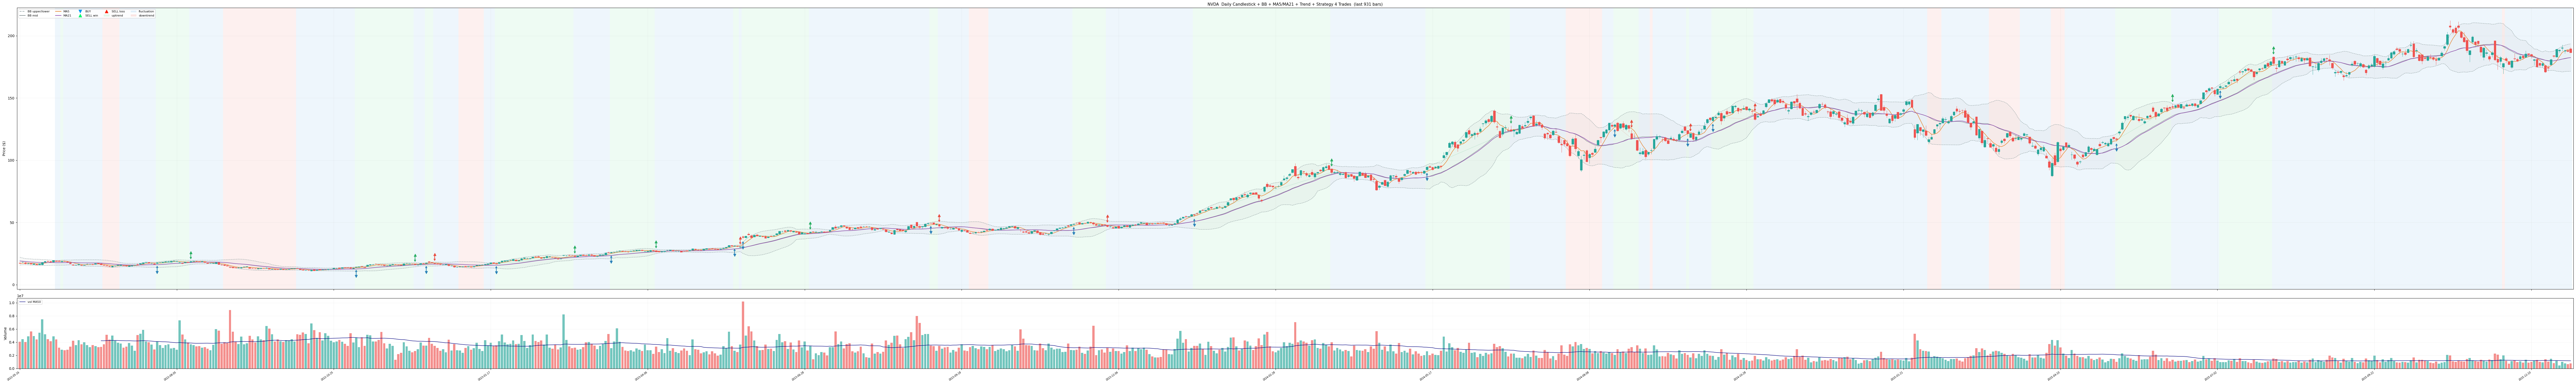

In [7]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

NBAR = 931

plot_df = (df.dropna(subset=['bb_mid', 'ma5', 'ma21', 'trend_13_21'])
             .tail(NBAR).reset_index(drop=True))
xs = np.arange(len(plot_df))
date_to_x = {d: i for i, d in enumerate(plot_df['date'])}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(100, 15), sharex=True,
                                gridspec_kw={'height_ratios': [4, 1]})

TREND_CLR = {'uptrend': '#d5f5e3', 'fluctuation': '#d6eaf8',
             'downtrend': '#fadbd8', 'unknown': 'white'}
seg_start, prev_t = 0, plot_df['trend_13_21'].iloc[0]
for i, t in enumerate(plot_df['trend_13_21']):
    if t != prev_t:
        ax1.axvspan(seg_start - 0.5, i - 0.5, color=TREND_CLR.get(prev_t, 'white'), alpha=0.40, lw=0)
        seg_start, prev_t = i, t
ax1.axvspan(seg_start - 0.5, len(plot_df) - 0.5, color=TREND_CLR.get(prev_t, 'white'), alpha=0.40, lw=0)

for i, row in plot_df.iterrows():
    up     = row['close'] >= row['open']
    body_c = '#26a69a' if up else '#ef5350'
    lo, hi = min(row['open'], row['close']), max(row['open'], row['close'])
    ax1.plot([i, i], [row['low'], row['high']], color=body_c, lw=0.7, zorder=2)
    ax1.add_patch(plt.Rectangle((i - 0.35, lo), 0.70, max(hi - lo, 0.01), color=body_c, zorder=3))

ax1.plot(xs, plot_df['bb_upper'], color='#95a5a6', lw=0.9, ls='--')
ax1.plot(xs, plot_df['bb_mid'],   color='#7f8c8d', lw=1.0, ls='-')
ax1.plot(xs, plot_df['bb_lower'], color='#95a5a6', lw=0.9, ls='--')
ax1.fill_between(xs, plot_df['bb_lower'], plot_df['bb_upper'], alpha=0.05, color='gray')
ax1.plot(xs, plot_df['ma5'],  color='#e67e22', lw=1.2, label='MA5')
ax1.plot(xs, plot_df['ma21'], color='#8e44ad', lw=1.2, label='MA21')

price_range = plot_df['high'].max() - plot_df['low'].min()
offset = price_range * 0.025

for _, t in tr4.iterrows():                          # <── tr4
    xi    = date_to_x.get(t['entry_date'])
    xo    = date_to_x.get(t['exit_date'])
    win_c = '#27ae60' if t['win'] else '#e74c3c'
    if xi is not None:
        low_here = plot_df.loc[xi, 'low']
        ax1.annotate('', xy=(xi, low_here - offset * 0.2), xytext=(xi, low_here - offset * 1.4),
                     arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.8), zorder=6)
        ax1.plot(xi, low_here - offset * 1.4, 'v', color='#2980b9', ms=7, zorder=6)
    if xo is not None:
        high_here = plot_df.loc[xo, 'high']
        ax1.annotate('', xy=(xo, high_here + offset * 0.2), xytext=(xo, high_here + offset * 1.4),
                     arrowprops=dict(arrowstyle='->', color=win_c, lw=1.8), zorder=6)
        ax1.plot(xo, high_here + offset * 1.4, '^', color=win_c, ms=7, zorder=6)
    if xi is not None and xo is not None:
        ax1.plot([xi, xo], [t['entry_price'], t['exit_price']],
                 color=win_c, lw=0.8, ls=':', alpha=0.6, zorder=5)

ax1.set_ylabel('Price ($)')
ax1.set_title(f'NVDA  Daily Candlestick + BB + MA5/MA21 + Trend + Strategy 4 Trades  (last {NBAR} bars)',
              fontsize=11)
ax1.grid(alpha=0.15)
ax1.set_xlim(-1, len(plot_df))

line_handles = [
    Line2D([0], [0], color='#95a5a6', ls='--', label='BB upper/lower'),
    Line2D([0], [0], color='#7f8c8d', ls='-',  label='BB mid'),
    Line2D([0], [0], color='#e67e22', lw=1.5,  label='MA5'),
    Line2D([0], [0], color='#8e44ad', lw=1.5,  label='MA21'),
    Line2D([0], [0], marker='v', color='#0797f7', ls='none', ms=8, label='BUY'),
    Line2D([0], [0], marker='^', color='#05f76a', ls='none', ms=8, label='SELL win'),
    Line2D([0], [0], marker='^', color='#f71c03', ls='none', ms=8, label='SELL loss'),
]
trend_handles = [
    Patch(facecolor='#d5f5e3', alpha=0.7, label='uptrend'),
    Patch(facecolor='#d6eaf8', alpha=0.7, label='fluctuation'),
    Patch(facecolor='#fadbd8', alpha=0.7, label='downtrend'),
]
ax1.legend(handles=line_handles + trend_handles, fontsize=8, loc='upper left', ncol=5, framealpha=0.85)

vol_c = ['#26a69a' if plot_df['close'].iloc[i] >= plot_df['open'].iloc[i] else '#ef5350'
         for i in range(len(plot_df))]
ax2.bar(xs, plot_df['volume'], color=vol_c, alpha=0.65, width=0.8)
ax2.plot(xs, plot_df['vol_ma50'], color='navy', lw=1.1, label='vol MA50')
ax2.set_ylabel('Volume')
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(alpha=0.15)

step = max(1, len(plot_df) // 16)
ax2.set_xticks(xs[::step])
ax2.set_xticklabels([str(plot_df['date'].iloc[i].date()) for i in xs[::step]],
                    rotation=35, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


## 8. 策略五：水上金叉（MACD）
DIF 从零轴**上方**上穿 DEA（水上金叉）→ 20% 建仓；遇死叉或满 10 天离场

In [41]:
def run_strat5_golden_cross(df, init_cash=INIT_CASH, buy_pct=0.20, fee=0.0005, hold_days=10):
    """
    水上金叉策略：
    - 入场：DIF 上穿 DEA 且 DIF > 0（零轴上方金叉）
    - 离场：DIF 下穿 DEA（死叉）或持满 hold_days 天，先到先得
    """
    df = df.dropna().reset_index(drop=True)
    cash, position, entry_bar, entry_price = init_cash, 0.0, None, None
    trades, equity_curve = [], []

    for i in range(1, len(df)):
        row   = df.iloc[i]
        prev  = df.iloc[i - 1]
        close = float(row['close'])
        date  = row['date']

        # ── Exit ──────────────────────────────────────
        if entry_bar is not None and position > 0:
            days_held   = i - entry_bar
            death_cross = (prev['dif'] > prev['dea']) and (row['dif'] <= row['dea'])
            do_sell     = death_cross or (days_held >= hold_days)

            if do_sell:
                reason   = 'Death Cross' if death_cross else f'Hold {days_held}d'
                proceeds = position * close
                cash    += proceeds * (1 - fee)
                cost     = entry_price * position * (1 + fee)
                trades.append({
                    'entry_date':  df.iloc[entry_bar]['date'],
                    'exit_date':   date,
                    'entry_price': entry_price,
                    'exit_price':  close,
                    'shares':      round(position, 4),
                    'cost':        round(cost, 2),
                    'proceeds':    round(proceeds, 2),
                    'pnl':         round(proceeds * (1 - fee) - cost, 2),
                    'reason':      reason,
                })
                position, entry_bar, entry_price = 0.0, None, None

        # ── Entry: water-above golden cross ───────────
        golden     = (prev['dif'] < prev['dea']) and (row['dif'] >= row['dea'])
        above_zero = row['dif'] > 0
        if golden and above_zero and entry_bar is None and cash > 0:
            spend       = cash * buy_pct
            shares      = spend / close
            cash       -= spend * (1 + fee)
            position    = shares
            entry_bar   = i
            entry_price = close

        equity_curve.append({'date': date, 'equity': cash + position * close})

    trades_df = pd.DataFrame(trades)
    if len(trades_df) > 0:
        trades_df['win']     = trades_df['pnl'] > 0
        trades_df['pnl_pct'] = trades_df['pnl'] / trades_df['cost'] * 100
    return pd.DataFrame(equity_curve), trades_df


eq5, tr5 = run_strat5_golden_cross(df)
s5 = win_rate_summary('5.Water-Above Golden Cross', tr5)

if len(tr5) > 0:
    print('\n卖出原因分布:')
    print(tr5['reason'].value_counts())
tr5

[5.Water-Above Golden Cross]  Trades=17  WinRate=41.2%  AvgPnL=$315.2  AvgWin=$1258.5  AvgLoss=$-345.1  R:R=3.65

卖出原因分布:
reason
Death Cross    10
Hold 10d        7
Name: count, dtype: int64


,entry_date,exit_date,entry_price,exit_price,shares,cost,proceeds,pnl,reason,win,pnl_pct
0,2022-08-15,2022-08-19,19.03,17.85,525.4861,10005.00,9379.93,-629.76,Death Cross,False,-6.294453
1,2022-11-30,2022-12-06,16.92,15.99,583.5725,9878.98,9331.32,-552.33,Death Cross,False,-5.590962
2,2022-12-12,2022-12-15,17.54,16.95,556.6467,9768.46,9435.16,-338.02,Death Cross,False,-3.460320
3,2023-03-16,2023-03-30,25.54,27.38,379.6389,9700.83,10394.51,688.49,Hold 10d,True,7.097228
4,2023-05-02,2023-05-03,28.21,27.80,348.5883,9838.59,9690.75,-152.68,Death Cross,False,-1.551848
5,2023-05-05,2023-05-12,28.68,28.34,341.8110,9808.04,9686.92,-125.96,Death Cross,False,-1.284253
6,2023-05-15,2023-05-30,28.95,40.11,337.7529,9782.84,13547.27,3757.66,Hold 10d,True,38.410727
7,2023-07-14,2023-07-21,45.47,44.31,231.5698,10534.74,10260.86,-279.02,Death Cross,False,-2.648570
8,2023-08-22,2023-09-06,45.67,47.06,229.3338,10478.91,10792.45,308.14,Hold 10d,True,2.940573
9,2023-12-15,2024-01-02,48.89,48.17,215.4900,10540.57,10380.15,-165.61,Death Cross,False,-1.571167


## 9. 策略六：震荡格网（EMA9/26 Cross + Grid）
EMA9 与 EMA26 出现交叉 → 判定为震荡市，以当天 VWAP 为 anchor 启动格网；
过去 20 个交易日无新交叉 → 强制清仓退出。
新交叉出现时 anchor = avg(上次交叉 VWAP, 本次 VWAP)。

In [42]:
from util_Grid import Strategy_GridTrading
from util_Grid import sell_partial as _grid_sell

def run_strat6_grid_ranging(df, init_cash=INIT_CASH, fee=0.0005,
                             grid_step=0.015, max_layers=5, stop_pct=0.15,
                             ranging_window=20):
    """
    震荡格网策略：
    - EMA9/EMA26 交叉 → 进入震荡模式，anchor = 当天 VWAP，启动格网
    - 新交叉出现 → anchor = avg(上次交叉 VWAP, 本次 VWAP)
    - 连续 ranging_window 天无交叉 → 强制清仓，记录期间 PnL
    """
    import warnings; warnings.filterwarnings('ignore')
    df = df.copy().reset_index(drop=True)

    # VWAP proxy（日线用 HLC/3 近似）
    df['vwap'] = (df['high'] + df['low'] + df['close']) / 3

    # EMA9 / EMA26 交叉检测
    ema9  = df['close'].ewm(span=9,  adjust=False).mean()
    ema26 = df['close'].ewm(span=26, adjust=False).mean()
    above = (ema9 > ema26).astype(int)
    df['ema_cross'] = (above.diff().abs() > 0).fillna(0).astype(int)

    # 初始化格网策略（计算 center / grid_step 列）
    strat = Strategy_GridTrading(
        center_n=20, grid_step=grid_step, max_layers=max_layers,
        stop_pct=stop_pct, maxPositionDays=60, reanchor_threshold=0.5
    )
    df = strat.prepare_indicators(df)

    state = {'cash': float(init_cash), 'position': 0.0, 'avg_price': np.nan,
             'entry_price': np.nan, 'trades': 0, 'fees_paid': 0.0, 'target_size': 0.0}
    # on_bar 中 Hard-Stop2 会访问 trade_log[-1]，给一个哨兵记录
    trade_log = [{'time': df['date'].iloc[0], 'trade_time': 0, 'anchor': np.nan,
                  'type': 'INIT', 'layer': 0, 'price': 0, 'size': 0, 'fee': 0,
                  'next_buy': np.nan, 'next_sell': np.nan, 'position_after': 0}]

    equity_curve  = []
    period_trades = []

    ranging_mode       = False
    last_cross_bar     = -999
    prev_cross_vwap    = None
    period_start_eq    = None
    period_start_date  = None
    period_start_price = None

    for i in range(1, len(df)):
        row   = df.iloc[i]
        close = float(row['close'])
        date  = row['date']

        is_cross = (row['ema_cross'] == 1) and (i >= 26)

        # ── 交叉事件 ──────────────────────────────────
        if is_cross:
            curr_vwap = float(row['vwap'])
            if not ranging_mode:
                ranging_mode       = True
                anchor             = curr_vwap
                period_start_eq    = state['cash'] + state['position'] * close
                period_start_date  = date
                period_start_price = close
                strat._reset_grid(anchor=anchor, layer=0, reset_layer_size=True)
            else:
                # 更新 anchor = 上次和本次 VWAP 的均值
                anchor = (prev_cross_vwap + curr_vwap) / 2 if prev_cross_vwap else curr_vwap
                strat._reset_grid(anchor=anchor, layer=strat.layer, reset_layer_size=False)
            prev_cross_vwap = curr_vwap
            last_cross_bar  = i

        # ── 超时强制清仓（无交叉超过 ranging_window 天）────
        if ranging_mode and (i - last_cross_bar) > ranging_window:
            ranging_mode = False
            if state['position'] > 0:
                _grid_sell(state, price=close, size=state['position'],
                           row_time=date, fee=fee)
            final_eq = state['cash'] + state['position'] * close
            period_trades.append({
                'entry_date':  period_start_date,
                'exit_date':   date,
                'entry_price': period_start_price,
                'exit_price':  close,
                'shares':      0,
                'cost':        round(period_start_eq, 2),
                'proceeds':    round(final_eq, 2),
                'pnl':         round(final_eq - period_start_eq, 2),
                'reason':      f'No Cross {ranging_window}d',
            })
            strat.anchor    = np.nan
            prev_cross_vwap = None

        # ── 格网运行 ───────────────────────────────────
        if ranging_mode:
            state['target_size'] = state['cash'] / close if close > 0 else 0
            strat.on_bar(i, date, row, state, fee=fee, trade_log=trade_log)

        equity_curve.append({'date': date,
                             'equity': state['cash'] + state['position'] * close})

    # 数据末尾仍在震荡模式 → 强制清仓
    if ranging_mode and state['position'] > 0:
        last_close = float(df['close'].iloc[-1])
        last_date  = df['date'].iloc[-1]
        _grid_sell(state, price=last_close, size=state['position'],
                   row_time=last_date, fee=fee)
        final_eq = state['cash']
        period_trades.append({
            'entry_date':  period_start_date,
            'exit_date':   last_date,
            'entry_price': period_start_price,
            'exit_price':  last_close,
            'shares':      0,
            'cost':        round(period_start_eq, 2),
            'proceeds':    round(final_eq, 2),
            'pnl':         round(final_eq - period_start_eq, 2),
            'reason':      'End of Data',
        })

    trades_df = pd.DataFrame(period_trades)
    if len(trades_df) > 0:
        trades_df['win']     = trades_df['pnl'] > 0
        trades_df['pnl_pct'] = trades_df['pnl'] / trades_df['cost'] * 100
    return pd.DataFrame(equity_curve), trades_df


eq6, tr6 = run_strat6_grid_ranging(df)
s6 = win_rate_summary('6.Grid Ranging (EMA Cross)', tr6)

if len(tr6) > 0:
    print('\n各震荡期出场:')
    print(tr6[['entry_date','exit_date','pnl','reason']].to_string())
tr6

max layer: 2022-06-13 00:00:00 ---
[Hard stop] 2022-06-30 00:00:00, new anchor = 16.952
max layer: 2022-07-01 00:00:00 ---
[Reset Grid]: 2022-08-01 00:00:00 position <= floor position
max layer: 2022-08-31 00:00:00 ---
[Hard stop] 2022-09-01 00:00:00, new anchor = 17.3695
max layer: 2022-09-02 00:00:00 ---
[Hard stop] 2022-09-06 00:00:00, new anchor = 16.8865
max layer: 2022-09-07 00:00:00 ---
[Hard stop] 2022-09-08 00:00:00, new anchor = 16.512
max layer: 2022-09-09 00:00:00 ---
[Hard stop] 2022-09-13 00:00:00, new anchor = 15.829500000000001
max layer: 2022-09-14 00:00:00 ---
[Hard stop] 2022-09-15 00:00:00, new anchor = 15.271499999999998
max layer: 2022-09-16 00:00:00 ---
[Hard stop] 2022-09-22 00:00:00, new anchor = 14.148000000000001
max layer: 2022-09-23 00:00:00 ---
[Reset Grid]: 2023-11-10 00:00:00 position <= floor position
[Reset Grid]: 2024-05-15 00:00:00 position <= floor position
max layer: 2024-07-30 00:00:00 ---
[Reset Grid]: 2024-09-25 00:00:00 position <= floor positi

,entry_date,exit_date,entry_price,exit_price,shares,cost,proceeds,pnl,reason,win,pnl_pct
0,2022-06-07,2022-07-13,18.93,15.16,0,50000.00,48466.03,-1533.97,No Cross 20d,False,-3.067940
1,2022-07-20,2022-08-18,17.81,18.77,0,48466.03,50843.03,2377.00,No Cross 20d,True,4.904466
2,2022-08-26,2022-09-27,16.26,12.41,0,50843.03,42278.53,-8564.50,No Cross 20d,False,-16.844983
3,2022-10-28,2022-11-29,13.83,15.64,0,42278.53,42278.53,0.00,No Cross 20d,False,0.000000
4,2022-12-27,2023-02-13,14.12,21.79,0,42278.53,42278.53,0.00,No Cross 20d,False,0.000000
5,2023-08-11,2023-12-07,40.86,46.60,0,42278.53,45253.96,2975.43,No Cross 20d,True,7.037686
6,2024-04-18,2024-06-04,84.67,116.44,0,45253.96,52481.72,7227.77,No Cross 20d,True,15.971575
7,2024-07-24,2024-10-23,114.25,139.56,0,52481.72,57294.45,4812.72,No Cross 20d,True,9.170279
8,2024-11-29,2025-03-26,138.25,113.76,0,57294.45,58788.51,1494.07,No Cross 20d,True,2.607705
9,2025-05-02,2025-06-03,114.50,141.22,0,58788.51,58788.51,0.00,No Cross 20d,False,0.000000


## 8. 汇总对比

In [43]:
summary = pd.DataFrame([s for s in [s1, s2, s3, s4, s5, s6] if s])
summary = summary.set_index('name')
print('\n==== 策略胜率汇总 ====')
print(summary.to_string())
summary


==== 策略胜率汇总 ====
                                trades  win_rate  avg_pnl  avg_win  avg_loss    rr
name                                                                              
1.BB Lower + TP8% SL5% Hold10d      17      70.6   531.55  1077.88   -779.66  1.38
2.BB Squeeze+MACD + TP8% SL5%        6      50.0   149.36   891.17   -592.46  1.50
3.Mean Reversion                    21      61.9   273.13   747.33   -497.46  1.50
4.Trend Following + TP10% SL5%      40      70.0   383.96   844.13   -689.78  1.22
5.Water-Above Golden Cross          17      41.2   315.22  1258.46   -345.05  3.65
6.Grid Ranging (EMA Cross)          12      50.0   738.05  3159.18  -1683.08  1.88


,trades,win_rate,avg_pnl,avg_win,avg_loss,rr
name,,,,,,
1.BB Lower + TP8% SL5% Hold10d,17,70.6,531.55,1077.88,-779.66,1.38
2.BB Squeeze+MACD + TP8% SL5%,6,50.0,149.36,891.17,-592.46,1.50
3.Mean Reversion,21,61.9,273.13,747.33,-497.46,1.50
4.Trend Following + TP10% SL5%,40,70.0,383.96,844.13,-689.78,1.22
5.Water-Above Golden Cross,17,41.2,315.22,1258.46,-345.05,3.65
6.Grid Ranging (EMA Cross),12,50.0,738.05,3159.18,-1683.08,1.88


## 9. 可视化：各策略净值 + 胜率对比

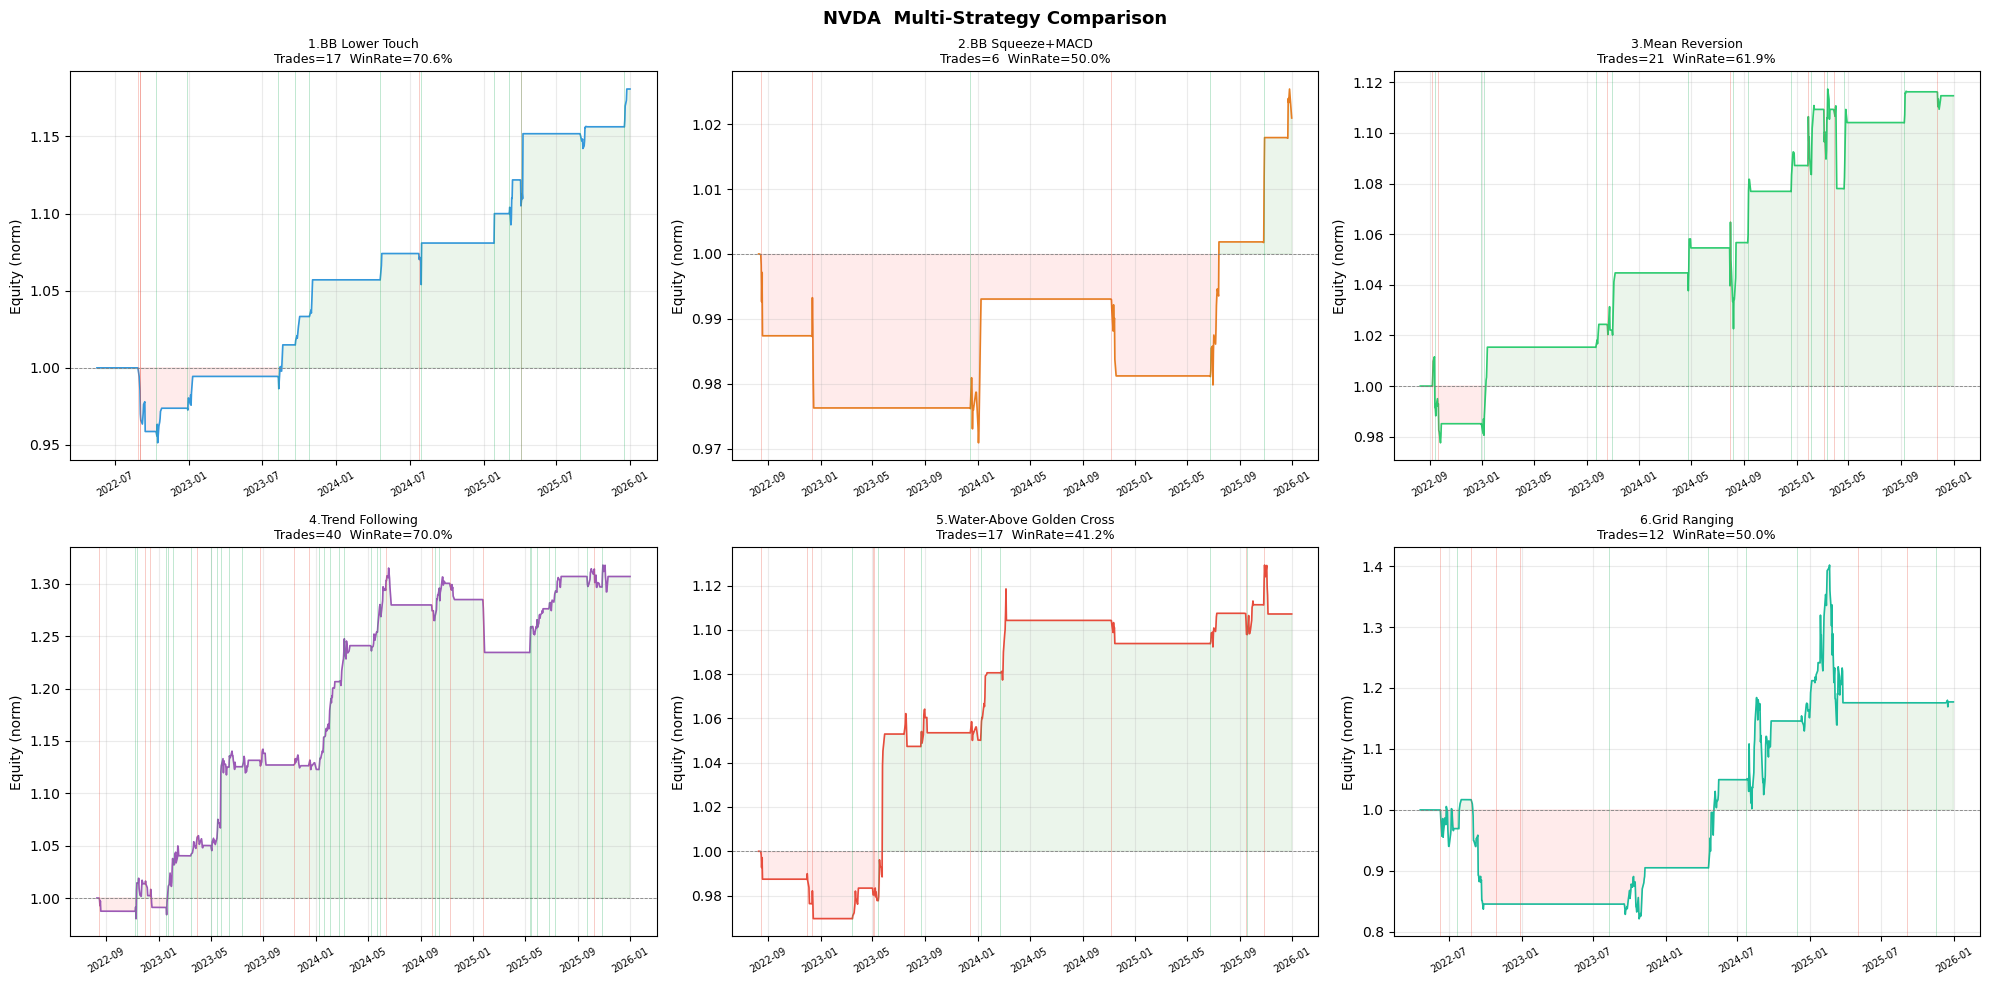

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

strats = [
    ('1.BB Lower Touch',           eq1, tr1, '#3498DB'),
    ('2.BB Squeeze+MACD',          eq2, tr2, '#E67E22'),
    ('3.Mean Reversion',           eq3, tr3, '#2ECC71'),
    ('4.Trend Following',          eq4, tr4, '#9B59B6'),
    ('5.Water-Above Golden Cross', eq5, tr5, '#E74C3C'),
    ('6.Grid Ranging',             eq6, tr6, '#1ABC9C'),
]

for ax, (name, eq, tr, color) in zip(axes, strats):
    if len(eq) == 0:
        ax.set_title(f'{name} — 无数据'); continue

    norm = eq['equity'] / eq['equity'].iloc[0]
    ax.plot(eq['date'], norm, color=color, lw=1.2)
    ax.axhline(1.0, color='gray', lw=0.6, ls='--')
    ax.fill_between(eq['date'], norm, 1.0, where=norm >= 1.0, alpha=0.08, color='green')
    ax.fill_between(eq['date'], norm, 1.0, where=norm < 1.0,  alpha=0.08, color='red')

    if len(tr) > 0:
        for _, t in tr.iterrows():
            c = '#27AE60' if t['win'] else '#E74C3C'
            ax.axvline(t['entry_date'], color=c, lw=0.5, alpha=0.4)

    wr  = tr['win'].mean() * 100 if len(tr) > 0 else 0
    cnt = len(tr)
    ax.set_title(f'{name}\nTrades={cnt}  WinRate={wr:.1f}%', fontsize=9)
    ax.set_ylabel('Equity (norm)')
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle(f'{SYMBOL}  Multi-Strategy Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'multistrat_{SYMBOL}_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 各策略每笔交易 PnL 分布

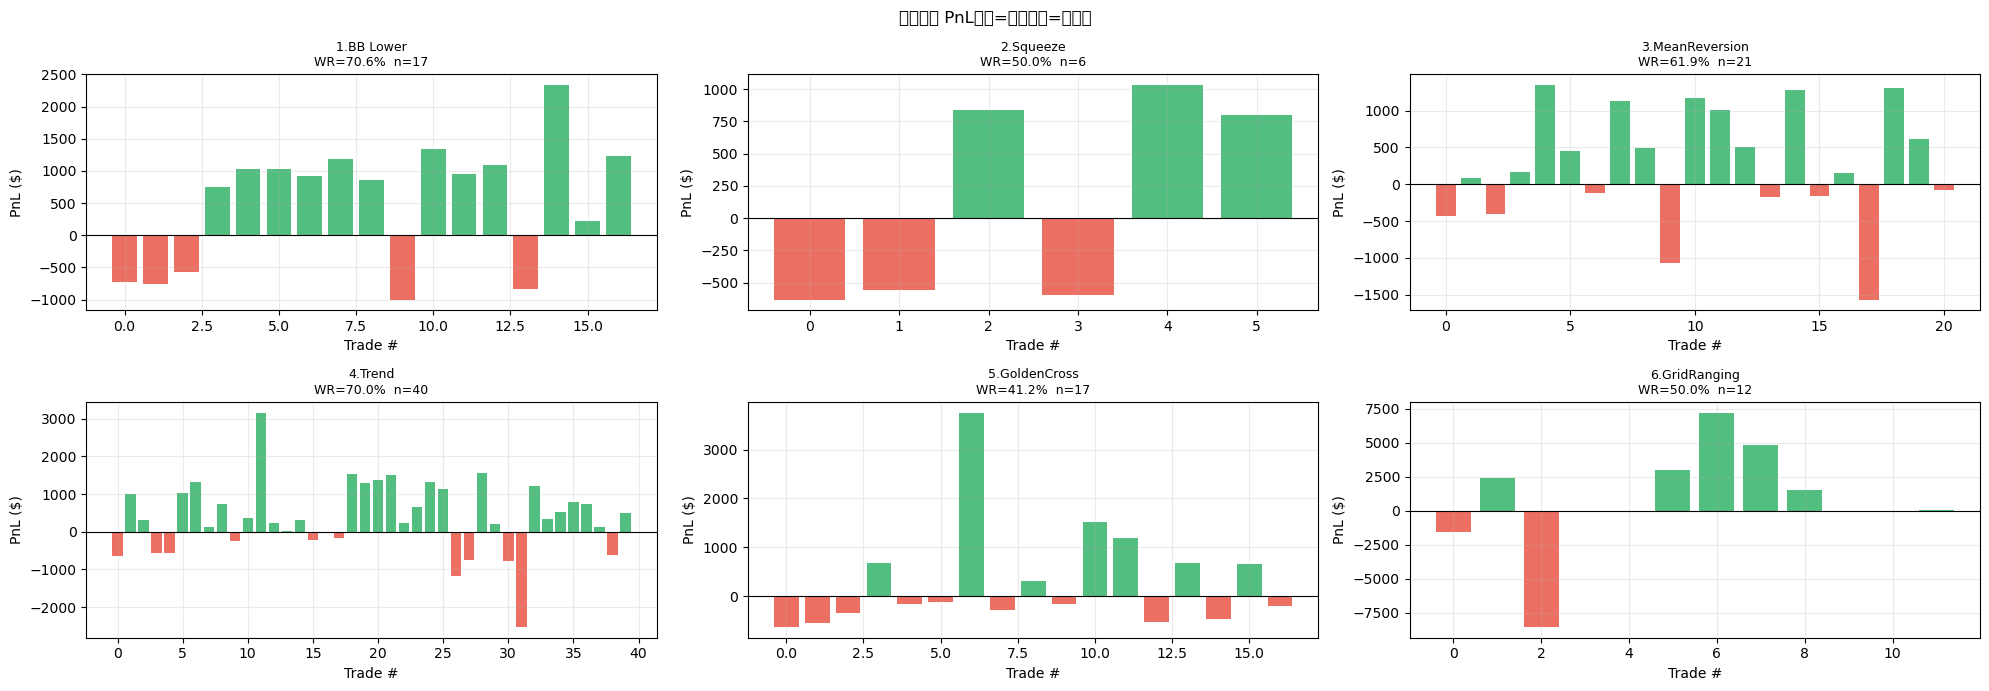

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(20, 7))
axes = axes.flatten()

strat_data = [
    ('1.BB Lower',      tr1, '#3498DB'),
    ('2.Squeeze',       tr2, '#E67E22'),
    ('3.MeanReversion', tr3, '#2ECC71'),
    ('4.Trend',         tr4, '#9B59B6'),
    ('5.GoldenCross',   tr5, '#E74C3C'),
    ('6.GridRanging',   tr6, '#1ABC9C'),
]
for ax, (name, tr, color) in zip(axes, strat_data):
    if len(tr) == 0:
        ax.set_title(f'{name}\n无交易'); continue
    colors = ['#27AE60' if w else '#E74C3C' for w in tr['win']]
    ax.bar(range(len(tr)), tr['pnl'].values, color=colors, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    wr = tr['win'].mean() * 100
    ax.set_title(f'{name}\nWR={wr:.1f}%  n={len(tr)}', fontsize=9)
    ax.set_xlabel('Trade #')
    ax.set_ylabel('PnL ($)')
    ax.grid(True, alpha=0.25)

plt.suptitle('每笔交易 PnL（绿=盈利，红=亏损）', fontsize=12)
plt.tight_layout()
plt.savefig(f'multistrat_{SYMBOL}_pnl_bars.png', dpi=150, bbox_inches='tight')
plt.show()